# Βήμα 3: Διερευνητική ανάλυση και μοντελοποίηση

Το notebook περιλαμβάνει τη διερευνητική ανάλυση των δεδομένων, τους στατιστικούς ελέγχους και την εκτίμηση των μοντέλων τιμής.

Η ανάλυση οργανώνεται γύρω από τρία ερευνητικά ερωτήματα:

1. Ποιοι παράγοντες σχετίζονται με την τιμή των καταλυμάτων;
2. Πώς διαφέρει το sentiment των κριτικών μεταξύ Αθήνας, Θεσσαλονίκης και Κρήτης;
3. Προσθέτει το sentiment πληροφορία για την τιμή πέρα από τα χαρακτηριστικά των καταλυμάτων και τις αριθμητικές βαθμολογίες;

Τα γραφήματα αποθηκεύονται στον φάκελο `figures/` και οι πίνακες αποτελεσμάτων στον φάκελο `tables/`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/thesis
!pip install -q shap

Mounted at /content/drive
/content/drive/MyDrive/thesis


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

os.makedirs('figures', exist_ok=True)
os.makedirs('tables', exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
REGION_ORDER = ['crete', 'athens', 'thessaloniki']
REGION_LABELS = {'crete': 'Κρήτη', 'athens': 'Αθήνα', 'thessaloniki': 'Θεσσαλονίκη'}

def save(fig, name):
    fig.savefig(f'figures/{name}.png', dpi=200, bbox_inches='tight')
    plt.show()

df = pd.read_csv('processed/listings_model.csv.gz')
df['region_label'] = df['region'].map(REGION_LABELS)
LABEL_ORDER = [REGION_LABELS[r] for r in REGION_ORDER]
print(df.shape)

(43567, 39)


# Μέρος Α: Διερευνητική ανάλυση
## Α1. Περιγραφικά στατιστικά ανά περιοχή

In [3]:
desc_cols = ['price', 'accommodates', 'bedrooms', 'n_amenities', 'review_scores_rating',
             'number_of_reviews', 'sent_mean', 'sent_neg_share', 'host_is_superhost']
desc_cols = [c for c in desc_cols if c in df.columns]
desc = df.groupby('region_label')[desc_cols].agg(['mean', 'median', 'std']).T.round(2)
desc = desc[LABEL_ORDER]
desc.to_csv('tables/descriptives_by_region.csv')
desc

region_label                  Κρήτη   Αθήνα  Θεσσαλονίκη
price                mean    245.19  130.66        85.33
                     median  150.00  105.00        75.50
                     std     239.31   87.47        39.66
accommodates         mean      4.78    3.76         3.74
                     median    4.00    4.00         4.00
                     std       2.69    1.91         1.71
bedrooms             mean      2.05    1.48         1.39
                     median    2.00    1.00         1.00
                     std       1.32    0.76         0.66
n_amenities          mean     41.77   35.44        33.55
                     median   41.00   36.00        35.00
                     std      17.76   12.90        13.01
review_scores_rating mean      4.85    4.78         4.74
                     median    4.95    4.87         4.85
                     std       0.28    0.36         0.39
number_of_reviews    mean     23.16   64.99        47.57
                     median    8.00   20.00        16.00
                     std      39.81  108.64        84.71
sent_mean            mean      0.72    0.68         0.64
                     median    0.76    0.73         0.68
                     std       0.19    0.21         0.22
sent_neg_share       mean      0.04    0.07         0.08
                     median    0.00    0.03         0.03
                     std       0.11    0.13         0.13
host_is_superhost    mean      0.45    0.49         0.41
                     median    0.00    0.00         0.00
                     std       0.50    0.50         0.49

## Α2. Κατανομή τιμών

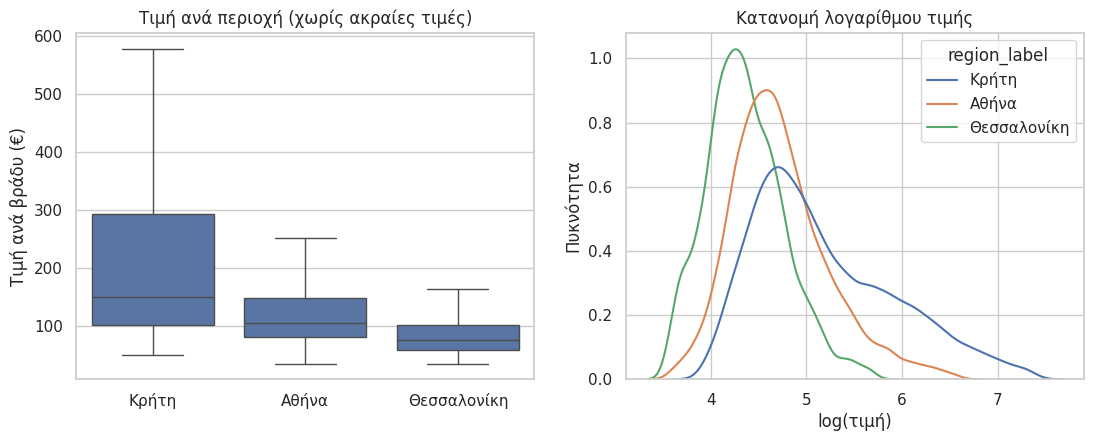

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x='region_label', y='price', order=LABEL_ORDER, showfliers=False, ax=axes[0])
axes[0].set(xlabel='', ylabel='Τιμή ανά βράδυ (€)', title='Τιμή ανά περιοχή (χωρίς ακραίες τιμές)')
sns.kdeplot(data=df, x='log_price', hue='region_label', hue_order=LABEL_ORDER, common_norm=False, ax=axes[1])
axes[1].set(xlabel='log(τιμή)', ylabel='Πυκνότητα', title='Κατανομή λογαρίθμου τιμής')
save(fig, 'price_distribution')

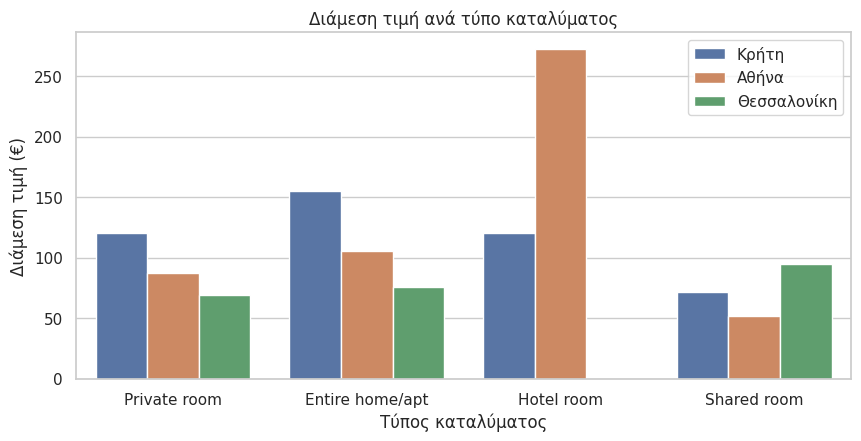

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=df, x='room_type', y='price', hue='region_label', hue_order=LABEL_ORDER,
            estimator=np.median, errorbar=None, ax=ax)
ax.set(xlabel='Τύπος καταλύματος', ylabel='Διάμεση τιμή (€)', title='Διάμεση τιμή ανά τύπο καταλύματος')
ax.legend(title='')
save(fig, 'price_by_room_type')

## Α3. Χάρτες τιμών

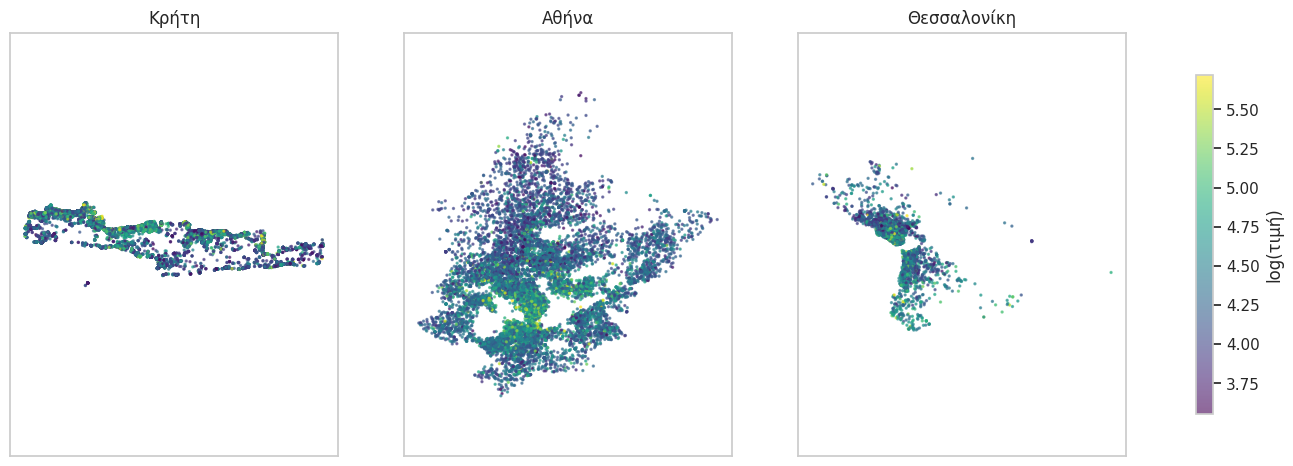

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, r in zip(axes, REGION_ORDER):
    d = df[df['region'] == r]
    sc = ax.scatter(d['longitude'], d['latitude'], c=d['log_price'], s=2, cmap='viridis', alpha=0.6)
    ax.set_title(REGION_LABELS[r]); ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal', adjustable='datalim')
fig.colorbar(sc, ax=axes, shrink=0.8, label='log(τιμή)')
save(fig, 'price_maps')

## Α4. Sentiment ανά περιοχή

Η ανάλυση σε επίπεδο καταλύματος περιορίζεται σε καταλύματα με τουλάχιστον τρεις διαθέσιμες κριτικές.

Το όριο χρησιμοποιείται ώστε να περιοριστεί η επίδραση μεμονωμένων κριτικών στον μέσο δείκτη sentiment, διατηρώντας παράλληλα επαρκές μέγεθος δείγματος. Η ευαισθησία των αποτελεσμάτων στο συγκεκριμένο όριο εξετάζεται επιπλέον στους ελέγχους ευρωστίας.

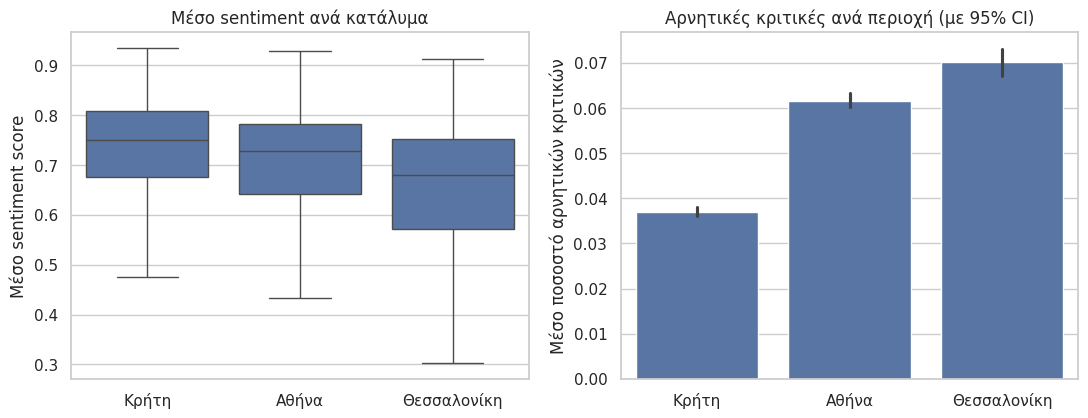

Kruskal-Wallis: H = 1221.9, p = 4.76e-266, epsilon² = 0.042


,σύγκριση,U,p (Bonferroni),διάμεσος 1,διάμεσος 2
0,Κρήτη vs Αθήνα,92830859.0,0.0,0.7498,0.7275
1,Κρήτη vs Θεσσαλονίκη,36380624.0,0.0,0.7498,0.6800
2,Αθήνα vs Θεσσαλονίκη,21521439.0,0.0,0.7275,0.6800


In [7]:
MIN_REVIEWS = 3
s = df[df['n_reviews_sent'] >= MIN_REVIEWS]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=s, x='region_label', y='sent_mean', order=LABEL_ORDER, showfliers=False, ax=axes[0])
axes[0].set(xlabel='', ylabel='Μέσο sentiment score', title='Μέσο sentiment ανά κατάλυμα')
sns.barplot(data=s, x='region_label', y='sent_neg_share', order=LABEL_ORDER, ax=axes[1])
axes[1].set(xlabel='', ylabel='Μέσο ποσοστό αρνητικών κριτικών', title='Αρνητικές κριτικές ανά περιοχή (με 95% CI)')
save(fig, 'sentiment_by_region')

# Στατιστικός έλεγχος: διαφέρει το sentiment ανάμεσα στις περιοχές;
groups = [s.loc[s['region'] == r, 'sent_mean'] for r in REGION_ORDER]
H, p = stats.kruskal(*groups)
n = sum(len(g) for g in groups)
eps2 = (H - len(groups) + 1) / (n - len(groups))  # μέγεθος επίδρασης (epsilon squared)
print(f'Kruskal-Wallis: H = {H:.1f}, p = {p:.3g}, epsilon² = {eps2:.3f}')

rows = []
for i in range(3):
    for j in range(i + 1, 3):
        a, b = groups[i], groups[j]
        U, pu = stats.mannwhitneyu(a, b)
        rows.append({'σύγκριση': f'{REGION_LABELS[REGION_ORDER[i]]} vs {REGION_LABELS[REGION_ORDER[j]]}',
                     'U': U, 'p (Bonferroni)': min(pu * 3, 1), 'διάμεσος 1': a.median(), 'διάμεσος 2': b.median()})
pairwise = pd.DataFrame(rows).round(4)
pairwise.to_csv('tables/sentiment_pairwise_tests.csv', index=False)
pairwise

## Α5. Έμμεσος έλεγχος συγκλίνουσας εγκυρότητας

Ως έμμεσος έλεγχος συγκλίνουσας εγκυρότητας εξετάζεται η συσχέτιση μεταξύ του μέσου sentiment score και της συνολικής αριθμητικής βαθμολογίας.

Μια θετική συσχέτιση αποτελεί ένδειξη ότι τα δύο μέτρα αποτυπώνουν σε κάποιο βαθμό κοινή πληροφορία σχετικά με την ικανοποίηση των επισκεπτών.

Η συγκεκριμένη ανάλυση δεν αποτελεί άμεση αξιολόγηση της ακρίβειας του μοντέλου sentiment.

,περιοχή,N,Spearman rho,p
0,Κρήτη,15629,0.331,0.0
1,Αθήνα,10285,0.624,0.0
2,Θεσσαλονίκη,3455,0.670,0.0
3,όλες,29369,0.488,0.0


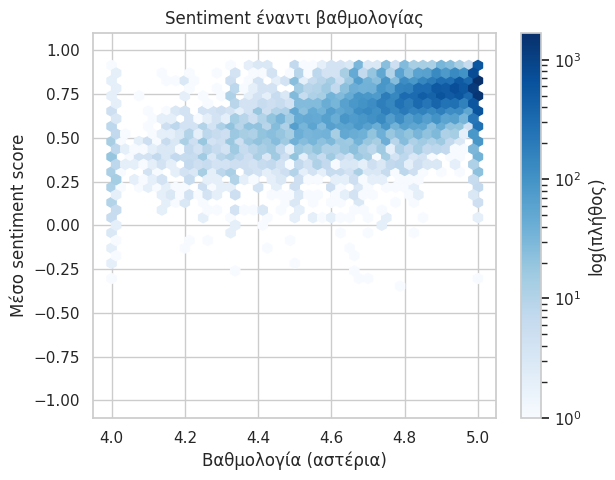

In [8]:
v = s.dropna(subset=['review_scores_rating'])
rows = []
for r in REGION_ORDER + ['όλες']:
    d = v if r == 'όλες' else v[v['region'] == r]
    rho, p = stats.spearmanr(d['sent_mean'], d['review_scores_rating'])
    rows.append({'περιοχή': REGION_LABELS.get(r, r), 'N': len(d), 'Spearman rho': round(rho, 3), 'p': p})
validity = pd.DataFrame(rows)
validity.to_csv('tables/sentiment_validity.csv', index=False)
display(validity)

fig, ax = plt.subplots(figsize=(6.5, 5))
hb = ax.hexbin(v['review_scores_rating'], v['sent_mean'], gridsize=40, bins='log', cmap='Blues',
               extent=(v['review_scores_rating'].quantile(0.01), 5, -1, 1))
ax.set(xlabel='Βαθμολογία (αστέρια)', ylabel='Μέσο sentiment score', title='Sentiment έναντι βαθμολογίας')
fig.colorbar(hb, label='log(πλήθος)')
save(fig, 'sentiment_vs_rating')

## Α6. Συσχετίσεις με την τιμή

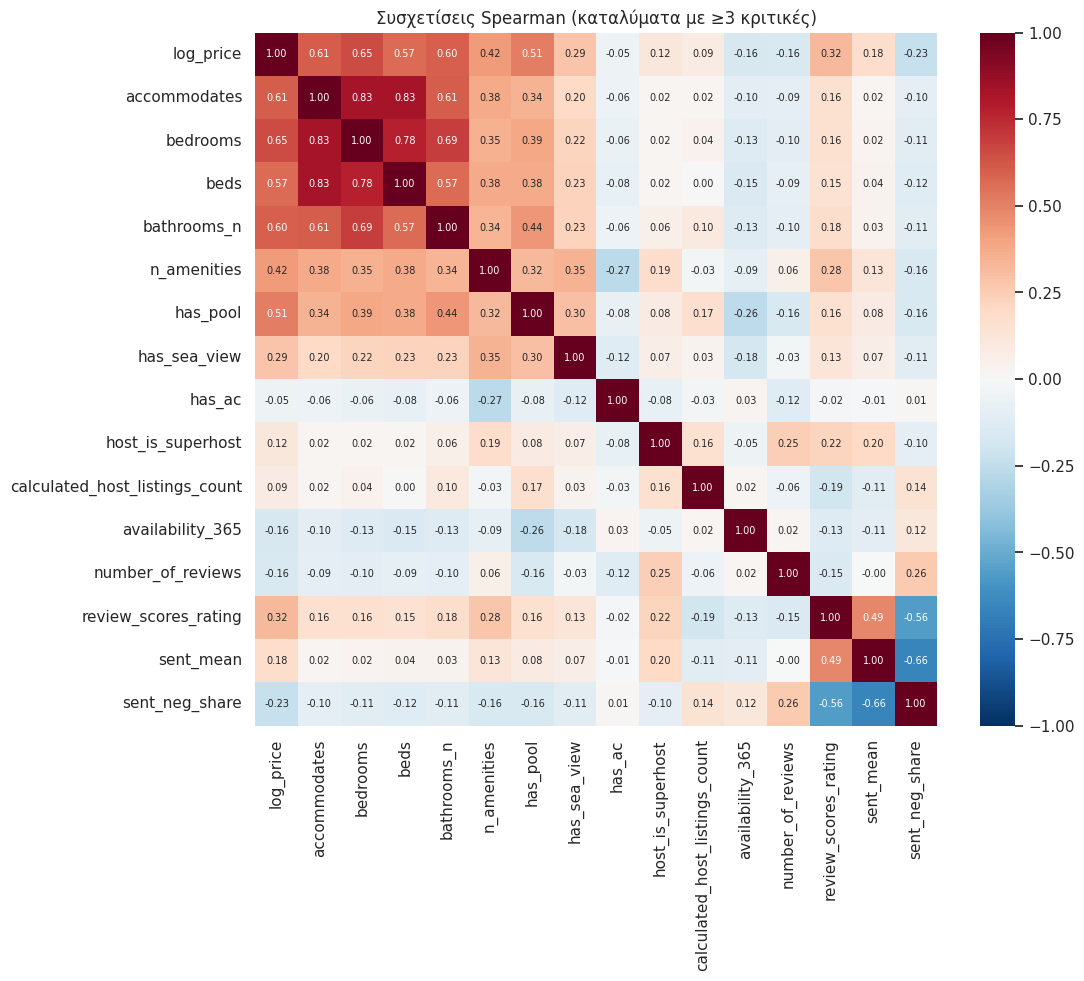

In [17]:
num_cols = ['log_price', 'accommodates', 'bedrooms', 'beds', 'bathrooms_n', 'n_amenities',
            'has_pool', 'has_sea_view', 'has_ac', 'host_is_superhost', 'host_tenure_years',
            'calculated_host_listings_count', 'availability_365', 'number_of_reviews',
            'review_scores_rating', 'sent_mean', 'sent_neg_share']
num_cols = [
    c for c in num_cols
    if c in s.columns and s[c].notna().any()
]
corr = s[num_cols].corr(method='spearman')
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 7}, ax=ax)
ax.set_title('Συσχετίσεις Spearman (καταλύματα με ≥3 κριτικές)')
save(fig, 'correlation_heatmap')

# Μέρος Β: Μοντέλα τιμής

Για την αξιολόγηση της πρόσθετης πληροφορίας του sentiment χρησιμοποιούνται τρεις εμφωλευμένες εκδοχές του μοντέλου στο ίδιο δείγμα:

- **Εκδοχή Α — Βασική:** χαρακτηριστικά καταλύματος, παροχές, χαρακτηριστικά οικοδεσπότη και τοποθεσία.
- **Εκδοχή Β — + Βαθμολογίες:** προστίθενται οι αριθμητικές βαθμολογίες και το πλήθος κριτικών.
- **Εκδοχή Γ — + Sentiment:** προστίθενται οι μεταβλητές sentiment.

Η σύγκριση των εκδοχών Β και Γ χρησιμοποιείται για την αξιολόγηση της πρόσθετης συνεισφοράς του sentiment πέρα από τις ήδη διαθέσιμες αριθμητικές βαθμολογίες.

Εξαρτημένη μεταβλητή είναι ο λογάριθμος της τιμής.

In [10]:
m = df[(df['n_reviews_sent'] >= MIN_REVIEWS) & df['review_scores_rating'].notna()].copy()

# Ομαδοποίηση των λιγότερο συχνών τύπων καταλύματος στην κατηγορία "Other"
top_pt = m['property_type'].value_counts().index[:12]
m['property_type_g'] = np.where(m['property_type'].isin(top_pt), m['property_type'], 'Other')

# Λογαριθμικός μετασχηματισμός επιλεγμένων μεταβλητών με έντονη δεξιά ασυμμετρία
m['log_min_nights'] = np.log1p(m['minimum_nights'].clip(upper=365))
m['log_host_listings'] = np.log1p(m['calculated_host_listings_count'])
m['log_n_reviews'] = np.log1p(m['number_of_reviews'])

BASE_NUM = ['accommodates', 'bedrooms', 'beds', 'bathrooms_n', 'bathroom_shared', 'n_amenities',
            'has_pool', 'has_ac', 'has_free_parking', 'has_sea_view', 'has_workspace', 'has_elevator',
            'has_balcony', 'has_self_checkin', 'host_is_superhost', 'host_response_rate',
            'host_tenure_years', 'log_host_listings', 'instant_bookable', 'log_min_nights',
            'availability_365', 'latitude', 'longitude']
STARS_NUM = ['review_scores_rating', 'review_scores_cleanliness', 'review_scores_location',
             'review_scores_value', 'log_n_reviews']
SENT_NUM = ['sent_mean', 'sent_neg_share']
# Η περιοχή καλύπτεται από τις γειτονιές (κάθε γειτονιά ανήκει σε μία περιοχή)
CAT = ['room_type', 'property_type_g', 'neighbourhood_cleansed']

BASE_NUM = [c for c in BASE_NUM if c in m.columns]
STARS_NUM = [c for c in STARS_NUM if c in m.columns]

def make_X(num_cols, verbose=False):
    X = m[num_cols].copy().replace([np.inf, -np.inf], np.nan)
    empty = [c for c in X.columns if X[c].isna().all()]
    if empty:
        if verbose:
            print('Αφαιρούνται στήλες χωρίς καμία τιμή:', empty)
        X = X.drop(columns=empty)
# Συμπλήρωση ελλειπουσών τιμών με τη διάμεσο και δημιουργία δείκτη απουσίας
    for c in list(X.columns):
        if X[c].isna().any():
            X[c + '_missing'] = X[c].isna().astype(int)
            X[c] = X[c].fillna(X[c].median())
    dummies = pd.get_dummies(m[CAT].astype(str), drop_first=True, dtype=int)
    X = pd.concat([X, dummies], axis=1)
    assert np.isfinite(X.to_numpy(dtype=float)).all(), 'Υπάρχουν ακόμα NaN/inf'
    return X

_ = make_X(BASE_NUM + STARS_NUM + SENT_NUM, verbose=True)

SPECS = {
    'Α: Βασικό': BASE_NUM,
    'Β: + Αστέρια': BASE_NUM + STARS_NUM,
    'Γ: + Sentiment': BASE_NUM + STARS_NUM + SENT_NUM,
}
y = m['log_price'].values
print(f'Δείγμα μοντέλων: {len(m):,} καταλύματα')
print(m['region'].value_counts())

Αφαιρούνται στήλες χωρίς καμία τιμή: ['host_response_rate', 'host_tenure_years', 'instant_bookable']
Δείγμα μοντέλων: 29,369 καταλύματα
region
crete           15629
athens          10285
thessaloniki     3455
Name: count, dtype: int64


## Β1. Γραμμική παλινδρόμηση (hedonic pricing)

Τα μοντέλα εκτιμώνται με OLS και τυπικά σφάλματα ανθεκτικά στην ετεροσκεδαστικότητα (HC1).

In [11]:
import statsmodels.api as sm

ols_results = {}
for name, cols in SPECS.items():
    X = sm.add_constant(make_X(cols).astype(float))
    ols_results[name] = sm.OLS(y, X).fit(cov_type='HC1')
    r = ols_results[name]
    print(f'{name:18s} R² = {r.rsquared:.3f}   adj. R² = {r.rsquared_adj:.3f}   N = {int(r.nobs):,}')

# Συντελεστές του πλήρους μοντέλου για τις βασικές μεταβλητές
full = ols_results['Γ: + Sentiment']
show = [c for c in BASE_NUM + STARS_NUM + SENT_NUM if c in full.params.index and c not in ('latitude', 'longitude')]
coef = pd.DataFrame({'coef': full.params[show], 'std err': full.bse[show], 'p': full.pvalues[show]})
coef['% επίδραση'] = (np.exp(coef['coef']) - 1) * 100
coef = coef.round(4)
coef.to_csv('tables/ols_full_coefficients.csv')
coef

Α: Βασικό          R² = 0.736   adj. R² = 0.735   N = 29,369
Β: + Αστέρια       R² = 0.757   adj. R² = 0.756   N = 29,369
Γ: + Sentiment     R² = 0.757   adj. R² = 0.756   N = 29,369


,coef,std err,p,% επίδραση
accommodates,0.0592,0.0026,0.0000,6.0960
bedrooms,0.1608,0.0055,0.0000,17.4415
beds,-0.0313,0.0027,0.0000,-3.0815
bathrooms_n,0.0976,0.0053,0.0000,10.2469
bathroom_shared,-0.1908,0.0271,0.0000,-17.3739
n_amenities,0.0036,0.0002,0.0000,0.3577
has_pool,0.3155,0.0080,0.0000,37.0891
has_ac,0.0485,0.0049,0.0000,4.9716
has_free_parking,-0.0037,0.0058,0.5253,-0.3704
has_sea_view,0.0832,0.0071,0.0000,8.6744


**Ερμηνεία των συντελεστών**

Επειδή η εξαρτημένη μεταβλητή είναι ο λογάριθμος της τιμής, η ακριβής ποσοστιαία μεταβολή της τιμής για μεταβολή Δx μιας συνεχούς μεταβλητής υπολογίζεται ως:

`100 × [exp(β × Δx) − 1]`

Για τη μεταβλητή `sent_mean`, μια μεταβολή κατά 0,1 αποτελεί πιο ρεαλιστική μονάδα ερμηνείας από μια μεταβολή κατά μία ολόκληρη μονάδα.

In [12]:
# Συμβατικός F-test εμφωλευμένων μοντέλων με OLS χωρίς robust τυπικά σφάλματα.
# Ο έλεγχος αναφέρεται χωριστά από τη συμπερασματολογία των συντελεστών με HC1.
Xb = sm.add_constant(make_X(SPECS['Β: + Αστέρια']).astype(float))
Xc = sm.add_constant(make_X(SPECS['Γ: + Sentiment']).astype(float))
rb, rc = sm.OLS(y, Xb).fit(), sm.OLS(y, Xc).fit()
f, pf, df_diff = rc.compare_f_test(rb)
print(f'F-test Γ έναντι Β: F = {f:.2f}, p = {pf:.3g}, επιπλέον μεταβλητές = {int(df_diff)}')

# Επίδραση του sentiment ανά περιοχή (το πλήρες μοντέλο χωριστά σε κάθε περιοχή)
rows = []
for r in REGION_ORDER:
    idx = (m['region'] == r).values
    Xr = make_X(SPECS['Γ: + Sentiment']).loc[idx]
    Xr = Xr.loc[:, Xr.nunique() > 1]
    res = sm.OLS(y[idx], sm.add_constant(Xr.astype(float))).fit(cov_type='HC1')
    for v in SENT_NUM:
        rows.append({'περιοχή': REGION_LABELS[r], 'μεταβλητή': v, 'coef': res.params[v],
                     'p': res.pvalues[v], 'R²': res.rsquared, 'N': int(res.nobs)})
by_region = pd.DataFrame(rows).round(4)
by_region.to_csv('tables/ols_sentiment_by_region.csv', index=False)
by_region

F-test Γ έναντι Β: F = 5.42, p = 0.00445, επιπλέον μεταβλητές = 2


/tmp/ipykernel_2116/2561448231.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  res = sm.OLS(y[idx], sm.add_constant(Xr.astype(float))).fit(cov_type='HC1')
/tmp/ipykernel_2116/2561448231.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  res = sm.OLS(y[idx], sm.add_constant(Xr.astype(float))).fit(cov_type='HC1')


,περιοχή,μεταβλητή,coef,p,R²,N
0,Κρήτη,sent_mean,-0.0292,0.4019,0.7662,15629
1,Κρήτη,sent_neg_share,0.0085,0.8906,0.7662,15629
2,Αθήνα,sent_mean,0.1470,0.0031,0.6265,10285
3,Αθήνα,sent_neg_share,0.2709,0.0005,0.6265,10285
4,Θεσσαλονίκη,sent_mean,0.2680,0.0002,0.5209,3455
5,Θεσσαλονίκη,sent_neg_share,0.3069,0.0046,0.5209,3455


## Β2. Μοντέλα μηχανικής μάθησης

Η προβλεπτική απόδοση των μοντέλων αξιολογείται με 5-fold cross-validation.

Χρησιμοποιούνται δύο μετρικές στον λογάριθμο της τιμής:
- RMSE
- R²

In [13]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

MODELS = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=150, min_samples_leaf=3, max_features=0.3, max_samples=0.5,
                                           n_jobs=-1, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8,
                            colsample_bytree=0.7, tree_method='hist', n_jobs=-1, random_state=42),
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for spec, cols in SPECS.items():
    X = make_X(cols).astype(float)
    for mname, model in MODELS.items():
        sc = cross_validate(model, X, y, cv=cv, scoring=('neg_root_mean_squared_error', 'r2'))
        rows.append({'εκδοχή': spec, 'μοντέλο': mname,
                     'RMSE': -sc['test_neg_root_mean_squared_error'].mean(),
                     'RMSE sd': sc['test_neg_root_mean_squared_error'].std(),
                     'R²': sc['test_r2'].mean()})
        print(f'{spec:18s} {mname:18s} RMSE = {rows[-1]["RMSE"]:.4f}  R² = {rows[-1]["R²"]:.4f}')

cv_results = pd.DataFrame(rows).round(4)
cv_results.to_csv('tables/model_comparison_cv.csv', index=False)
cv_results.pivot(index='μοντέλο', columns='εκδοχή', values='R²')

Α: Βασικό          Linear Regression  RMSE = 0.3461  R² = 0.7330
Α: Βασικό          Random Forest      RMSE = 0.3082  R² = 0.7883
Α: Βασικό          XGBoost            RMSE = 0.2960  R² = 0.8047
Β: + Αστέρια       Linear Regression  RMSE = 0.3322  R² = 0.7541
Β: + Αστέρια       Random Forest      RMSE = 0.3041  R² = 0.7939
Β: + Αστέρια       XGBoost            RMSE = 0.2861  R² = 0.8176
Γ: + Sentiment     Linear Regression  RMSE = 0.3322  R² = 0.7541
Γ: + Sentiment     Random Forest      RMSE = 0.3057  R² = 0.7918
Γ: + Sentiment     XGBoost            RMSE = 0.2865  R² = 0.8171


εκδοχή,Α: Βασικό,Β: + Αστέρια,Γ: + Sentiment
μοντέλο,,,
Linear Regression,0.7330,0.7541,0.7541
Random Forest,0.7883,0.7939,0.7918
XGBoost,0.8047,0.8176,0.8171


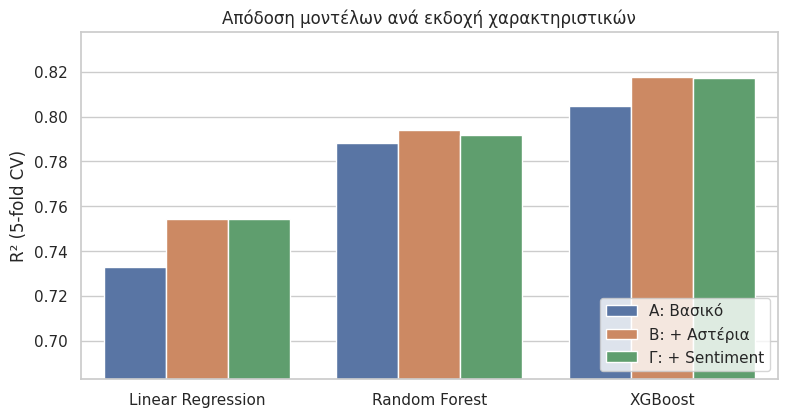

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=cv_results, x='μοντέλο', y='R²', hue='εκδοχή', ax=ax)
ax.set(xlabel='', ylabel='R² (5-fold CV)', title='Απόδοση μοντέλων ανά εκδοχή χαρακτηριστικών')
ax.set_ylim(cv_results['R²'].min() - 0.05, cv_results['R²'].max() + 0.02)
ax.legend(title='', loc='lower right')
save(fig, 'model_comparison')

## Β3. Ερμηνεία του XGBoost με SHAP

Οι τιμές SHAP χρησιμοποιούνται για την εκτίμηση της σχετικής συνεισφοράς κάθε μεταβλητής στις προβλέψεις του XGBoost και για την εξέταση της κατεύθυνσης των επιδράσεων στο προβλεπόμενο αποτέλεσμα.

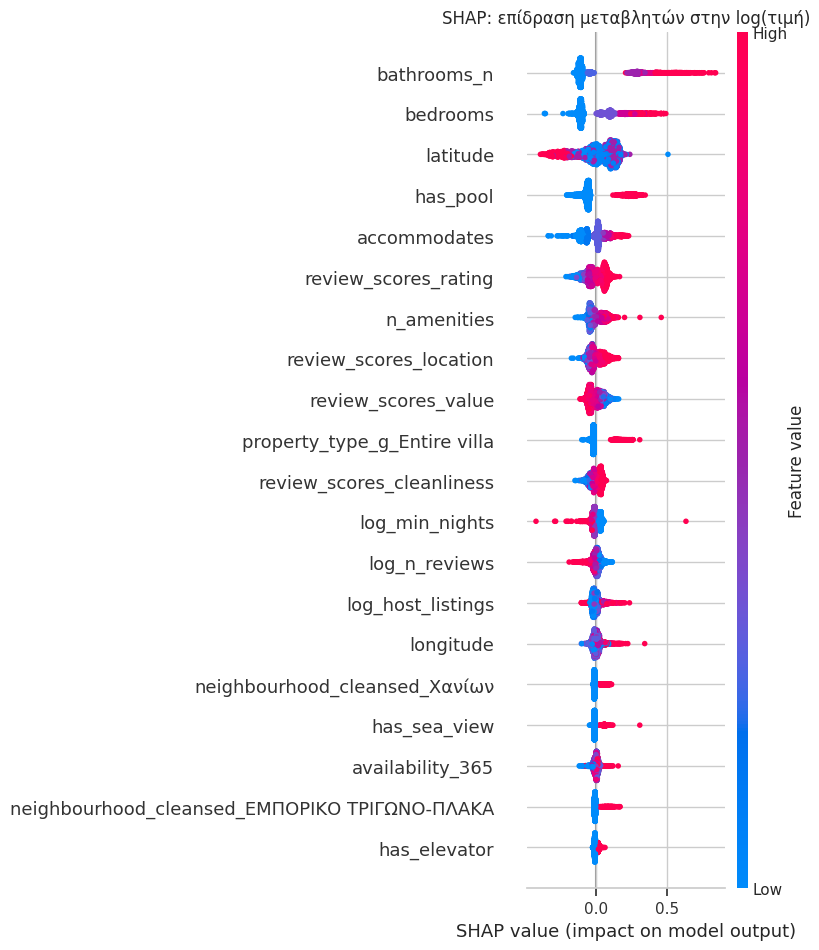

Θέση των μεταβλητών sentiment στη σειρά σπουδαιότητας:
  sent_mean: #21 από 119
  sent_neg_share: #30 από 119


In [15]:
import shap

X_full = make_X(SPECS['Γ: + Sentiment']).astype(float)
xgb = MODELS['XGBoost'].fit(X_full, y)
X_sample = X_full.sample(min(3000, len(X_full)), random_state=42)
shap_values = shap.TreeExplainer(xgb).shap_values(X_sample)

plt.figure()
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('SHAP: επίδραση μεταβλητών στην log(τιμή)')
save(plt.gcf(), 'shap_summary')

imp = pd.Series(np.abs(shap_values).mean(axis=0), index=X_sample.columns).sort_values(ascending=False)
imp.head(25).round(4).to_csv('tables/shap_importance.csv')
print('Θέση των μεταβλητών sentiment στη σειρά σπουδαιότητας:')
for v in SENT_NUM:
    print(f'  {v}: #{list(imp.index).index(v) + 1} από {len(imp)}')

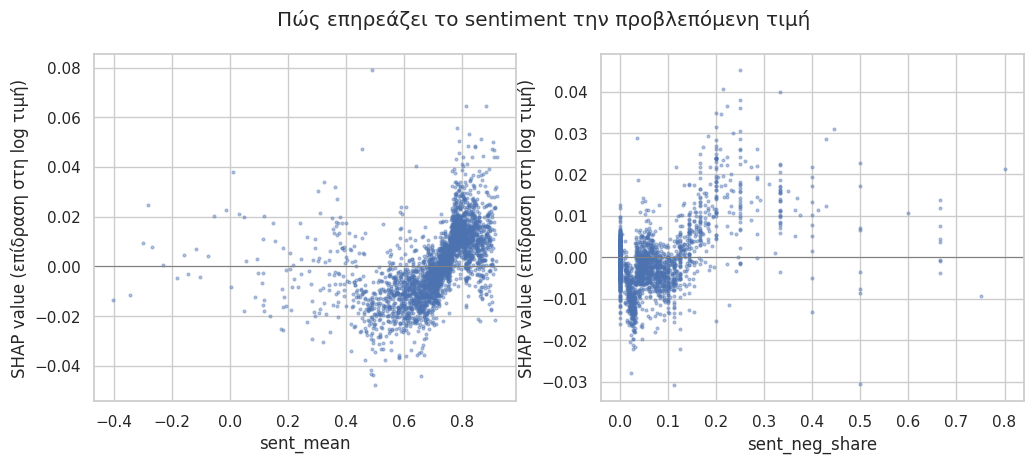

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, v in zip(axes, SENT_NUM):
    j = list(X_sample.columns).index(v)
    ax.scatter(X_sample[v], shap_values[:, j], s=4, alpha=0.4)
    ax.axhline(0, color='grey', lw=0.8)
    ax.set(xlabel=v, ylabel='SHAP value (επίδραση στη log τιμή)')
fig.suptitle('Πώς επηρεάζει το sentiment την προβλεπόμενη τιμή')
save(fig, 'shap_sentiment_dependence')